# **Atividade Prática**
<font size=3>

- **Tema:** autocomplete.
- **Prazo de entrega:** 15 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Vamos realizar uma tarefa de **_autocomplete_** com o conjundo de dados [IMDB movie reviews](https://keras.io/api/datasets/imdb/), também disponível no diretório $\text{dataset/}\,$. Nesta tarefa, iremos encontrar o próximo *token* mais provável. Para isso, realize os seguintes passos atentamente:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e realize uma amostragem dos dados a fim de capturar 500 textos de revisão;
- Defina os dados textuais em uma lista.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [2]:
from collections import Counter
from keras import layers, Model
import keras_tuner as kt
from keras.metrics import SparseTopKCategoricalAccuracy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorboard
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.preprocessing.sequence import pad_sequences

RANDOM_STATE = 42

In [3]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))
#tf.debugging.set_log_device_placement(True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
N_SAMPLES_TRAIN = 2_000
N_SAMPLES_TEST = 500

df = (
    pd.read_csv("./dataset/imdb.csv")
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

df_test = (
    df
    .iloc[
        N_SAMPLES_TRAIN:
        N_SAMPLES_TRAIN + N_SAMPLES_TEST
    ]
    .copy()
)

df = (
    df
    .iloc[:N_SAMPLES_TRAIN]
    .copy()
)

print("Desenvolvimento:", df.shape)
print("Teste externo:  ", df_test.shape)

df.head()

Desenvolvimento: (2000, 2)
Teste externo:   (500, 2)


,reviews,label
0,River's Edge is more than just the story of a ...,1
1,Evening is the beautiful story of the flawed l...,1
2,I question anyone saying they don't care for t...,1
3,This docu-drama is what you would expect from ...,1
4,"As several posters have ""hinted,"" this is a so...",0


In [5]:
def Preprocessor(x):

    # tudo em minúsculo
    x = tf.strings.lower(x)

    # remove tags html
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")

    # remove links http
    x = tf.strings.regex_replace(x, r"http\S+", " ")

    # replace \n by space
    x = tf.strings.regex_replace(x, r"\\n", " ")

    # remove caracteres especiais
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")

    # remove espaços em excesso
    x = tf.strings.regex_replace(x, r" {2,}", " ")

    # remove espaços extras no início e no final
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


2026-06-10 22:19:38.592272: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-06-10 22:19:38.592296: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-10 22:19:38.592302: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1781140778.592315 8623578 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781140778.592335 8623578 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
df_reviews = df[["reviews"]].copy()
df_reviews["reviews"] = df_reviews["reviews"].map(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)
df_reviews.head(5).style.set_properties(
    subset=["reviews"],
    **{"white-space": "pre-wrap", "max-width": "800px", "text-align": "left"}
)

,reviews
0,rivers edge is more than just the story of a murder its an indictment of the wave of apathy that has plagued pockets of youth for decades now our main characters are a group of what my high school would have referred to as stoners one of them just decided to strangle his girlfriend because she apparently had the nerve to talk sht to him this dangerous young man played by daniel roebuck has an intensity that will startle you he takes the other kids in the group out to show them his girlfriends body and strangely enough nobody seems really freaked out about it the balance of the film punctuates the desperate circumstances in which these people live and how guilt is eventually able to worm its way inside even these apathetic kids rivers edge is certainly not condoning or championing the behavior of its characters we clearly see the dangers presented by such unchecked apathy and having only the desire to get drunk or high we are shown the dysfunctional home lives these kids have and perhaps this is meant to explain their awful behavior but could it only be unstable homes that lead to this type of destructive living crispin glover is his usual whackedout self he drives around town in a state of complete paranoia after the murder he tries to sympathize with why his friend had to commit the crime but clearly he does not understand what could have made the young man do it dennis hopper plays an older man these kids get their dope from though he is certainly a rebellious figure he cannot relate to the apathy and rage of the younger generation witness his confused reaction as roebuck describes how killing his girlfriend made him feel as wild as hoppers character is even he knows this young man should not be walking the face of the earth what will you think of these kids well there is really no way to like their characters some are less despicable than others but you cannot help either hating or feeling sorry for them twenty years later there is still an apathy alive and well in a great many young people out there when do these kids get lost what makes so many of them want to act antisocial this film and the questions it poses about teenagers will stick with you for a while thats a fact 8 of 10 stars the hound
1,evening is the beautiful story of the flawed love of a mother the movie split in time is magically shot amazingly acted and has a touching script vanessa redgrave plays anne grant lord a woman sunsetting out of life lying in her bed her mind remembering and misfiring she recalls her first mistake claire danes plays the young anne giving a youthful vitality to dying bed ridden woman daughters nina toni collette and constance natasha richardson try to decipher the real story from the disheartening dementia her first mistake revolves around harris arden patrick wilson the man her best friend lila mamie gummer deeply loved the daughters must come to terms with their mothers past and their futures the cast is glowing in evening the collective acting energy of this movie could have powered the equipment for the production of this entire film i am so glad to see claire danes working again especially in this role she is so young and alive fully living the joys mistakes and heartbreak of young annes first mistake this is a true feat when you realize she is playing a woman dying in bed when her life overwhelms her you can feel her desire to crack and her hopeless hope that she wont some of her facial expressions grinded on me a little but over all her performance was so radiant i was left with that only as a side note toni collette continues to prove that you can be a powerful actress without being a super model she plays the black sheep of the family a little lost nina finds a great deal of strength in her mothers mistake collette delicately avoids creating a cruel character who revels in the mistakes of her mother instead choosing the wiser path of learning from her mothers mistakes there is a great deal of infighting between 

In [7]:
print(f"Quantidade de amostras: {len(df)}")

print("\nValores ausentes (NaN):")
print(df[["reviews"]].isna().sum())

Quantidade de amostras: 2000

Valores ausentes (NaN):
reviews    0
dtype: int64


In [8]:
tokens = " ".join(df_reviews["reviews"]).split()
token_counts = Counter(tokens)

token_counts.most_common(20)

[('the', 27514),
 ('and', 13426),
 ('a', 13230),
 ('of', 12039),
 ('to', 11117),
 ('is', 8556),
 ('in', 7675),
 ('it', 6396),
 ('i', 6045),
 ('this', 5990),
 ('that', 5635),
 ('was', 3966),
 ('as', 3702),
 ('with', 3626),
 ('for', 3492),
 ('but', 3448),
 ('movie', 3320),
 ('film', 3139),
 ('on', 2823),
 ('you', 2468)]

In [9]:
df_reviews["length"] = df_reviews["reviews"].str.split().str.len()
df_reviews["length"].describe()


count    2000.000000
mean      235.413500
std       179.976566
min        25.000000
25%       127.000000
50%       171.000000
75%       284.000000
max      2088.000000
Name: length, dtype: float64

In [10]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")
    
def formatar_numero_br(x, casas_decimais=1):
    '''
    Formata um número utilizando vírgula como separador decimal
    e ponto como separador de milhar.
    '''
    return (
        f"{x:,.{casas_decimais}f}"
        .replace(",", "_")
        .replace(".", ",")
        .replace("_", ".")
    )


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True,
    casas_decimais=1
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos
    marcar no gráfico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x / 1_000_000,
                    casas_decimais
                )
            )
        )
        xlabel = f"{nome} em milhões"
    else:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x,
                    casas_decimais
                )
            )
        )
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            if usar_milhoes:
                valor_formatado = (
                    f"{formatar_numero_br(valor / 1_000_000, casas_decimais)} mi"
                )
            else:
                valor_formatado = formatar_numero_br(valor, casas_decimais)

            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}: {valor_formatado}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(
        f"Distribuição de {nome} até o percentil "
        f"{int(limite_percentil * 100)}"
    )
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

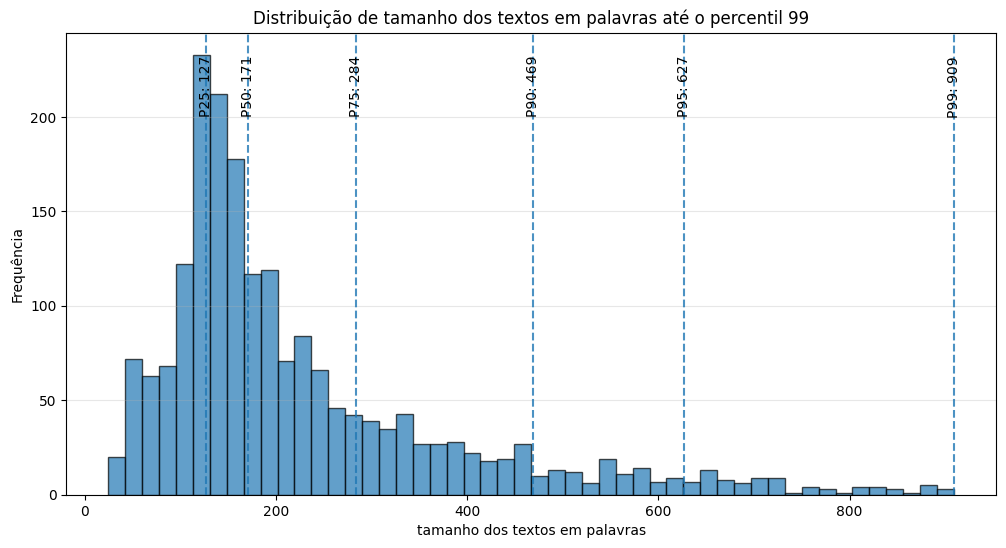

In [11]:
plotar_histograma_com_percentis(
    df_reviews["length"],
    nome="tamanho dos textos em palavras",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False,
    casas_decimais=0
)


In [12]:
token_counts = Counter(
    token
    for comment in df_reviews["reviews"]
    for token in comment.split()
)
# Ordena os tokens do mais frequente para o menos frequente
frequencias_ordenadas = sorted(token_counts.values(), reverse=True)

total_ocorrencias = sum(frequencias_ordenadas)
total_tokens_unicos = len(frequencias_ordenadas)

print(f"Total de ocorrências de palavras: {br_number(total_ocorrencias)}")
print(f"Quantidade de palavras distintas: {br_number(total_tokens_unicos)}")

Total de ocorrências de palavras: 470.827
Quantidade de palavras distintas: 30.016


In [13]:
vocab_sizes = [
     2_500,
     5_000,
     7_500,
    10_000,
    12_500,
    15_000
]

In [14]:
resultados_vocabulario = []

for vocab_size in vocab_sizes:
    tamanho_efetivo = min(vocab_size, total_tokens_unicos)

    ocorrencias_cobertas = sum(frequencias_ordenadas[:tamanho_efetivo])
    ocorrencias_oov = total_ocorrencias - ocorrencias_cobertas

    resultados_vocabulario.append({
        "VOCAB_SIZE": vocab_size,
        "palavras incluídas": tamanho_efetivo,
        "ocorrências cobertas": ocorrencias_cobertas,
        "cobertura (%)": ocorrencias_cobertas / total_ocorrencias * 100,
        "ocorrências OOV": ocorrencias_oov,
        "OOV (%)": ocorrencias_oov / total_ocorrencias * 100
    })

df_vocabulario = pd.DataFrame(resultados_vocabulario)

df_vocabulario.style.format({
    "VOCAB_SIZE": "{:,.0f}",
    "palavras incluídas": "{:,.0f}",
    "ocorrências cobertas": "{:,.0f}",
    "cobertura (%)": "{:.2f}",
    "ocorrências OOV": "{:,.0f}",
    "OOV (%)": "{:.2f}"
})

,VOCAB_SIZE,palavras incluídas,ocorrências cobertas,cobertura (%),ocorrências OOV,OOV (%)
0,"2,500","2,500","396,694",84.25,"74,133",15.75
1,"5,000","5,000","423,000",89.84,"47,827",10.16
2,"7,500","7,500","436,382",92.68,"34,445",7.32
3,"10,000","10,000","444,899",94.49,"25,928",5.51
4,"12,500","12,500","450,639",95.71,"20,188",4.29
5,"15,000","15,000","455,639",96.77,"15,188",3.23


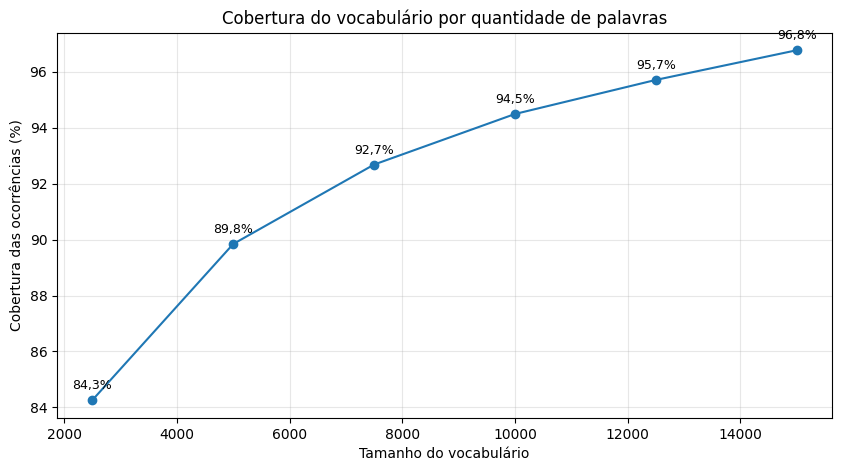

In [15]:
def plotar_cobertura_vocabulario():
    plt.figure(figsize=(10, 5))

    plt.plot(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"],
        marker="o"
    )

    for x, y in zip(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"]
    ):
        plt.annotate(
            f"{y:.1f}%".replace(".", ","),
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

    plt.title("Cobertura do vocabulário por quantidade de palavras")
    plt.xlabel("Tamanho do vocabulário")
    plt.ylabel("Cobertura das ocorrências (%)")
    plt.grid(True, alpha=0.3)

    plt.show()

plotar_cobertura_vocabulario()

Nos passos seguintes, vamos gerar, a partir de cada review, sequências de tokens com tamanho máximo igual a 16. Cada sequência será utilizada como entrada para que o modelo aprenda a prever o token seguinte.

Antes de gerar essas sequências, é necessário separar os conjuntos de treinamento e teste. Essa separação deve ser realizada no nível das reviews completas, e não no nível das sequências geradas. Caso contrário, trechos muito semelhantes de uma mesma review podem aparecer simultaneamente nos dois conjuntos. Nessa situação, o modelo seria avaliado com sequências muito próximas daquelas utilizadas durante o treinamento, produzindo métricas excessivamente otimistas.

O vocabulário também deve ser construído utilizando apenas as reviews do conjunto de treinamento. Dessa forma, informações específicas dos textos reservados para teste não influenciam a preparação do modelo. Palavras que aparecem apenas no conjunto de teste serão representadas pelo token `[UNK]`.

Como as reviews possuem comprimentos variados, cada uma delas gera uma quantidade diferente de sequências. Portanto, uma separação contendo 80% das reviews para treinamento e 20% para teste não necessariamente produzirá a mesma proporção entre as sequências geradas. Após a divisão, é necessário verificar a quantidade de amostras resultante em cada conjunto e avaliar se a proporção permanece adequada. Dado que queremos janelas deslizantes de *até* 16 tokens, admitindo janelas com menos tokens (preenchidos por padding), podemos facilmente calcular o numero de sequencias geradas a partir de cada documento como sendo: `sequence_count = length - 1`. Vamos então adicionar essa coluna no `df_reviews`


In [16]:
df_reviews["sequence_count"] = (
    df_reviews["length"] - 1
).clip(lower=0)

df_reviews["sequence_count"].describe()

count    2000.000000
mean      234.413500
std       179.976566
min        24.000000
25%       126.000000
50%       170.000000
75%       283.000000
max      2087.000000
Name: sequence_count, dtype: float64

In [17]:
# df_train, df_test = train_test_split(
#     df_reviews,
#     test_size=0.2,
#     random_state=RANDOM_STATE
# )
df_test = df_test[["reviews"]].copy()

df_test["reviews"] = df_test["reviews"].map(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)

df_test["reviews"] = (
    Preprocessor(
        tf.constant(
            df_test["reviews"].tolist()
        )
    )
    .numpy()
    .astype(str)
)

df_test["length"] = (
    df_test["reviews"]
    .str.split()
    .str.len()
)

df_test["sequence_count"] = (
    df_test["length"] - 1
).clip(lower=0)

df_train, df_val = train_test_split(
    df_reviews,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [18]:
datasets = {
    "Treino": df_train,
    "Validação": df_val,
    "Teste": df_test,
}

total_reviews = len(df_reviews)
total_sequences = df_reviews["sequence_count"].sum()

print(f"Total de reviews:    {total_reviews:,}")
print(f"Total de sequências: {total_sequences:,}")

for name, dataset in datasets.items():
    review_count = len(dataset)
    sequence_count = dataset["sequence_count"].sum()

    print(f"\n{name}")
    print(
        f"Reviews:    {review_count:,} "
        f"({review_count / total_reviews:.2%})"
    )
    print(
        f"Sequências: {sequence_count:,} "
        f"({sequence_count / total_sequences:.2%})"
    )
    print(dataset["sequence_count"].describe())

Total de reviews:    2,000
Total de sequências: 468,827

Treino
Reviews:    1,600 (80.00%)
Sequências: 377,932 (80.61%)
count    1600.000000
mean      236.207500
std       180.968255
min        24.000000
25%       126.000000
50%       170.000000
75%       287.000000
max      2087.000000
Name: sequence_count, dtype: float64

Validação
Reviews:    400 (20.00%)
Sequências: 90,895 (19.39%)
count    400.000000
mean     227.237500
std      175.993595
min       30.000000
25%      123.000000
50%      166.000000
75%      253.750000
max      993.000000
Name: sequence_count, dtype: float64

Teste
Reviews:    500 (25.00%)
Sequências: 113,662 (24.24%)
count     500.000000
mean      227.324000
std       189.058364
min        24.000000
25%       125.750000
50%       169.000000
75%       269.000000
max      2458.000000
Name: sequence_count, dtype: float64


### **2º Passo:**
<font size=3>

- Realize a indexação dos textos, utilizando a a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - Considere, *inicialmente*, um vocabulário de tamanho 5000;
    - Faça a indexação sem preenchimento (*padding*). Para isso, defina as variáveis `output_sequence_length = None` e `ragged = True`.
    <br>

- Defina a lista de vocabulário por meio do método `get_vocabulary` do objeto de `TextVectorization`;

- Defina os dados indexados com o nome `token_ids`.


In [19]:
texts_train = df_train["reviews"].tolist()
texts_val = df_val["reviews"].tolist()
texts_test = df_test["reviews"].tolist()

In [20]:
VOCAB_SIZE = 5_000
MAX_LEN = 16

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=Preprocessor,
    output_sequence_length=None,
    ragged=True,
    output_mode="int",
)

# Aprende o vocabulário exclusivamente com os textos de treino.
vectorizer.adapt(texts_train)

vocab = np.array(
    vectorizer.get_vocabulary()
)

vocab[:10]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it'],
      dtype='<U16')

### **3º Passo:**
<font size=3>

- O *array* `token_ids` é formado por vetores indexados de tamanhos distintos. Mas, agora, iremos decompor cada vetor, *e.g.* $[2,\, 5,\, 3,\, 1,\, 8]$, como sequências do "próximo *token*":
$$
    [2,\, 5],\, [2,\, 5,\, 3],\, [2,\, 5,\, 3,\, 1],\, [2,\, 5,\, 3,\, 1,\, 8]
$$

- Assim, defina uma lista `sequences` que irá capturar as sequências de **todos** os vetores;

- Utilize a função [`pad_sequences`]() para preencher as sequências da esqueda para a direira:
$$
    [ 0,\, 0,\, 0,\, 2,\, 5],\, [0,\, 0,\, 2,\, 5,\, 3],\, [0,\, 2,\, 5,\, 3,\, 1],\, [2,\, 5,\, 3,\, 1,\, 8]
$$
    - Defina o tamanho da entrada da rede `max_len = 16`;
    - Defina as variáveis da função `maxlen = max_len+1` e `padding = "pre"`.
  

#### Resolucao item 3

O problema com a abordagem de padding a esquerda sugerida é que ela impede a utilizacao de algumas otimizações necessarias para processar corretamente o padding pela rede neural. Tentamos inicialmente utilizar a abordagem sugerida, porém o resultado gerou treinamento lento por não permitir utilizar algumas das possibilidades de otimização oferecidas pelo Keras. Então vamos adotar uma abordagem inversa: queremos queremos que as frases sofram padding à direita. Com isso, vamos aproveitar e montar os arrays X e y numa unica etapa. 

É importante a notar também que as frases possuem tamanhos variáveis, como foi mostrado nos passos anteriores. Como vamos trabalhar com uma janela de contexto de 16 tokens, montar sequencias maiores que 16 tokens é disperdicio de tempo e espaço. Vamos trabalhar então com uma janela deslizante de até 16 tokens sobre cada texto Por fim, cada texto pode gerar uma grande quantidade de amostras de sequencias. 

In [21]:
def gerar_sequencias(
    texts,
    vectorizer,
    max_len,
    ignorar_target_unk=True
):
    token_ids = vectorizer(texts).to_list()

    contexts = []
    targets = []

    for document_ids in token_ids:
        for target_position in range(1, len(document_ids)):
            target = document_ids[target_position]

            if ignorar_target_unk and target == 1:
                continue

            start_position = max(
                0,
                target_position - max_len
            )

            contexts.append(
                document_ids[start_position:target_position]
            )

            targets.append(
                target
            )

    X = pad_sequences(
        contexts,
        maxlen=max_len,
        padding="post",
        truncating="pre"
    )

    y = np.array(
        targets,
        dtype=np.int32
    )

    return X, y

### **4º Passo:**
<font size=3>

- Agora, iremos definir as variáveis $X$ e $y$ do modelo:
    - Onde $X$ serão as sequências até o **penúltimo elemento**, *e.g.*, $[ 0,\, 0,\, 0,\, 2]$;
    - e $y$ serão o **último elemento** das sequências, *e.g.*, $[5]$.
    <br>

- Verifique se $X$ apresenta dimensão `max_len`;


In [22]:
X_train, y_train = gerar_sequencias(
    texts_train,
    vectorizer,
    MAX_LEN
)

X_val, y_val = gerar_sequencias(
    texts_val,
    vectorizer,
    MAX_LEN
)

X_test, y_test = gerar_sequencias(
    texts_test,
    vectorizer,
    MAX_LEN
)

In [23]:
print("Treino:   ", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:    ", X_test.shape, y_test.shape)

Treino:    (340022, 16) (340022,)
Validação: (80427, 16) (80427,)
Teste:     (100552, 16) (100552,)


In [24]:

print(X_train.shape)
print(y_train.shape)
n = 8
print(X_train[:n])
print(y_train[:n])

(340022, 16)
(340022,)
[[ 11   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 11  13   1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 11  13   1 143   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 11  13   1 143   2   0   0   0   0   0   0   0   0   0   0   0]
 [ 11  13   1 143   2  97   0   0   0   0   0   0   0   0   0   0]
 [ 11  13   1 143   2  97  20   1   0   0   0   0   0   0   0   0]
 [ 11  13   1 143   2  97  20   1   3   0   0   0   0   0   0   0]
 [ 11  13   1 143   2  97  20   1   3 197   1   0   0   0   0   0]]
[ 13 143   2  97  20   3 197  16]


### **5º Passo:**
<font size=3>

- Desenvolva a rede neural:
    - Já sabemos do tamanho da camada de entrada, mas a **camada de saída** deverá *retornar qual o próximo token mais provável da lista de vocabulário*.
    - **Observação:** aqui, talvez, você ache incompatível a variável algo $y$ com a camada de saída, mas iremos dar um jeito na função de custo, a seguir.
      

In [25]:
#EMBED_DIM = 256
EMBED_DIM = 100 # para fazer transfer learning com o GloVe

In [26]:
GLOVE_PATH = "./dataset/glove.6B.100d.txt"

embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Vetores GloVe carregados: {len(embeddings_index)}")


Vetores GloVe carregados: 400000


In [27]:
vocab = vectorizer.get_vocabulary()
num_tokens = len(vocab)

embedding_matrix = np.zeros((num_tokens, EMBED_DIM), dtype="float32")

hits = 0
misses = 0

for i, word in enumerate(vocab):
    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Tokens encontrados no GloVe: {hits}")
print(f"Tokens não encontrados.....: {misses}")
print(f"Cobertura..................: {hits / num_tokens:.2%}")

Tokens encontrados no GloVe: 4959
Tokens não encontrados.....: 41
Cobertura..................: 99.18%


In [28]:
x_in = layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input")
#x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="embedding")(x_in)
x = layers.Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix],
    mask_zero=True,
    trainable=False,
    name="glove_embedding"
)(x_in)
x = layers.LSTM(256, return_sequences=False, name="lstm")(x)
#x = layers.LSTM(128, return_sequences=False, name="lstm")(x)
x = layers.Dropout(0.2, name="dropout")(x)
#x = layers.Dense(256, activation="relu", name="dense1")(x)
#x = layers.Dense(1600, activation="relu", name="dense3")(x)
x_out = layers.Dense(VOCAB_SIZE, activation="softmax", name="output")(x)

model = Model(x_in, x_out)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 16, 100)   │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 16)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    365,568 │ glove_embedding[… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5000)      │  1,285,000 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,150,568 (8.20 MB)

 Trainable params: 1,650,568 (6.30 MB)

 Non-trainable params: 500,000 (1.91 MB)

### **6º Passo:**
<font size=3>

- Compile o modelo com:
    - Otimizador `Adam`;
    - Para lidar com **saídas probabilística** e **variável alvo categórica**, utilizaremos a **função de custo** [`sparse_categorical_crossentropy`](https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class);
    - Métrica [`SparseTopKCategoricalAccuracy`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/SparseTopKCategoricalAccuracy) para pegar os $k=5$ maiores valores da camada de saída.


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss="sparse_categorical_crossentropy", 
              metrics=[SparseTopKCategoricalAccuracy(k=5, name="SparseTopKCategoricalAccuracy")]
              )

### **7º Passo:**
<font size=3>

- Realize o **treinamento validativo** do modelo com:
    - 15 épocas (inicialmente);
    - `batch_size` > 100;
    - `validation_split = 0.2`.
      

In [ ]:
model.fit(x=X_train , 
          y=y_train, 
          epochs=15, 
          batch_size=256, 
          validation_data=(X_val, y_val)
          )




In [ ]:
UNK_ID = 1

def analisar_targets(y, nome):
    total = len(y)
    unk_count = np.sum(y == UNK_ID)

    print(nome)
    print(f"Total de sequências: {total:,}")
    print(f"Targets [UNK]:       {unk_count:,}")
    print(f"Proporção [UNK]:     {unk_count / total:.2%}")
    print()


analisar_targets(y_train, "Treino")
analisar_targets(y_val, "Validação")
analisar_targets(y_test, "Teste")

#### Analisando targets UNK

In [ ]:
def exibir_targets_mais_frequentes(y, vocab, quantidade=10):
    ids, counts = np.unique(
        y,
        return_counts=True
    )

    ordem = np.argsort(
        counts
    )[::-1]

    total = len(y)

    for token_id, count in zip(
        ids[ordem][:quantidade],
        counts[ordem][:quantidade]
    ):
        print(
            f"{token_id:4d} "
            f"{vocab[token_id]:15s} "
            f"{count:6d} "
            f"{count / total:7.2%}"
        )


print("Treino")
exibir_targets_mais_frequentes(
    y_train,
    vocab
)

print("\nValidação")
exibir_targets_mais_frequentes(
    y_val,
    vocab
)

In [ ]:
def calcular_baseline_top_k(
    y_train,
    y_eval,
    k=5
):
    ids, counts = np.unique(
        y_train,
        return_counts=True
    )

    top_k_ids = ids[
        np.argsort(counts)[-k:]
    ]

    accuracy = np.mean(
        np.isin(y_eval, top_k_ids)
    )

    return top_k_ids, accuracy


top_5_ids, baseline_val = calcular_baseline_top_k(
    y_train,
    y_val,
    k=5
)

print("Tokens previstos pelo baseline:")
for token_id in top_5_ids:
    print(
        token_id,
        repr(vocab[token_id])
    )

print(
    f"\nBaseline top-5 na validação: "
    f"{baseline_val:.2%}"
)

In [ ]:
UNK_ID = 1

def remover_targets_unk(X, y):
    mask = y != UNK_ID

    return X[mask], y[mask]

In [ ]:
X_train, y_train = remover_targets_unk(
    X_train,
    y_train
)

X_val, y_val = remover_targets_unk(
    X_val,
    y_val
)

X_test, y_test = remover_targets_unk(
    X_test,
    y_test
)

In [ ]:
print("Treino:   ", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:    ", X_test.shape, y_test.shape)

In [29]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

model.compile(
    optimizer=Adam(
        learning_rate=3e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

history = model.fit(
    x=X_train,
    y=y_train,
    epochs=40,
    batch_size=256,
    validation_data=(
        X_val,
        y_val
    ),
    callbacks=callbacks
)

Epoch 1/40


2026-06-10 22:20:03.527443: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 6.3386 - top_5_accuracy: 0.1921 - val_loss: 6.0499 - val_top_5_accuracy: 0.2219 - learning_rate: 3.0000e-04
Epoch 2/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - loss: 6.0494 - top_5_accuracy: 0.2267 - val_loss: 5.8388 - val_top_5_accuracy: 0.2469 - learning_rate: 3.0000e-04
Epoch 3/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 5.8727 - top_5_accuracy: 0.2465 - val_loss: 5.7088 - val_top_5_accuracy: 0.2621 - learning_rate: 3.0000e-04
Epoch 4/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - loss: 5.7460 - top_5_accuracy: 0.2590 - val_loss: 5.6116 - val_top_5_accuracy: 0.2731 - learning_rate: 3.0000e-04
Epoch 5/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - loss: 5.6469 - top_5_accuracy: 0.2691 - val_loss: 5.5423 - val_top_5_accuracy: 0.2820 - learning_rate: 3.0000e-04
Epoch 6/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - loss: 5.5666 - top_5_accuracy: 0.2767 - val_loss: 5.4885 - val_top_5_accuracy: 0.2884 - learn

### **8º Passo:**
<font size=3>

Realize o **treinamento final** (sem validação) da melhor arquitetura que conseguiu modelar.

### **9º Passo:**
<font size=3>

- Defina uma função para **gerar** o próximo *token* dado uma entrada de texto:
    - O texto deve entrar na forma de *string*, *e.g.*, "the movie was", então a função deverá utilizar o objeto de `TextVectorization`, já definido, para obter os tokens indexados;
    - Em seguinda, o *array* de tokens indexados deverá passar pelo `pad_sequences`, com tamanho `max_len`;
    - Realize a predição do modelo e utilize a função `argmax` do `Numpy` para encontrar o índice do *token* mais provável;
    - Com este índice, use a lista de vocabulário para encontrar o *token* mais provável;
    - Anexe este token à sentença de entrada;
    - Coloque toda a estrutura de código dos itens acima em um *loop*, a fim de gerar as $n$ palavras mais provaveis. 
    <br>

- Seu modelo precisa completar ao menos **três palavras coerentes** com a frase de entrada.
      

In [60]:
frases_teste = [
    "the movie was",
    "the acting was",
    "the soundtrack was",
    "what i liked the most was",
    "the ending of the film was",
]

In [58]:
def gerar_proximas_palavras(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    n=3
):
    """
    Gera as próximas palavras de forma determinística,
    selecionando sempre o token mais provável.
    """

    # Aplica o mesmo vectorizer utilizado durante o treinamento.
    ids = (
        vectorizer([texto])
        .to_list()[0]
    )

    novas = []

    for _ in range(n):
        # Preserva apenas os tokens mais recentes e aplica padding à direita.
        x = pad_sequences(
            [ids[-max_len:]],
            maxlen=max_len,
            padding="post",
            truncating="pre"
        )

        # Calcula a distribuição de probabilidades da próxima palavra.
        probs = modelo.predict(
            x,
            verbose=0
        )[0].copy()

        # Bloqueia tokens que não devem ser gerados.
        probs[0] = 0  # padding
        probs[1] = 0  # [UNK]

        # Seleciona a palavra mais provável.
        next_id = int(
            np.argmax(probs)
        )

        ids.append(next_id)
        novas.append(
            vocab[next_id]
        )

    return novas

In [61]:

for frase_original in frases_teste:
    novas = gerar_proximas_palavras(
        modelo=model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        n=8
    )

    frase_gerada = (
        frase_original
        + " "
        + " ".join(novas)
    )

    print(f"Frase original: {frase_original}")
    print(f"Frase gerada:   {frase_gerada}")
    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a great movie i saw this movie i
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was a good good movie i saw this movie
----------------------------------------------------------------------------------------------------
Frase original: the soundtrack was
Frase gerada:   the soundtrack was a great movie i saw this movie i
----------------------------------------------------------------------------------------------------
Frase original: what i liked the most was
Frase gerada:   what i liked the most was a great movie i saw it i was
----------------------------------------------------------------------------------------------------
Frase original: the ending of the film was
Frase gerada:   the ending of the film was a great movie i saw it to be
---------------------------------------------------------------------------

In [33]:
def comparar_contexto_com_frequencia_global(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    y_train,
    k=15
):
    ids = vectorizer([texto]).to_list()[0]

    x = pad_sequences(
        [ids[-max_len:]],
        maxlen=max_len,
        padding="post",
        truncating="pre"
    )

    probs = modelo.predict(
        x,
        verbose=0
    )[0].copy()

    probs[0] = 0  # padding
    probs[1] = 0  # [UNK]

    global_counts = np.bincount(
        y_train,
        minlength=len(vocab)
    )

    global_probs = (
        global_counts / global_counts.sum()
    )

    top_ids = np.argsort(
        probs
    )[-k:][::-1]

    print(f"\nContexto: {texto}\n")
    print(
        f"{'token':15s} "
        f"{'contexto':>10s} "
        f"{'global':>10s} "
        f"{'razão':>8s}"
    )

    for token_id in top_ids:
        contextual = probs[token_id]
        global_prob = global_probs[token_id]

        razao = (
            contextual / global_prob
            if global_prob > 0
            else np.inf
        )

        print(
            f"{vocab[token_id]:15s} "
            f"{contextual:9.3%} "
            f"{global_prob:9.3%} "
            f"{razao:8.2f}"
        )

In [34]:
for frase_original in frases_teste:

    comparar_contexto_com_frequencia_global(
        modelo=model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        y_train=y_train,
        k=15
    )


Contexto: the movie was

token             contexto     global    razão
a                 18.542%    3.120%     5.94
the                5.879%    6.460%     0.91
one                4.564%    0.510%     8.96
an                 4.030%    0.426%     9.47
not                1.859%    0.569%     3.27
bad                1.825%    0.155%    11.75
so                 1.640%    0.390%     4.20
very               1.614%    0.251%     6.43
my                 1.528%    0.234%     6.54
great              1.374%    0.173%     7.95
made               1.341%    0.152%     8.80
just               1.177%    0.365%     3.22
to                 0.968%    2.628%     0.37
good               0.949%    0.263%     3.60
it                 0.946%    1.503%     0.63

Contexto: we liked

token             contexto     global    razão
this              20.904%    1.365%    15.31
that              12.367%    1.339%     9.24
the                5.337%    6.460%     0.83
a                  4.922%    3.120%     1.58
to  

Agora vamos remover a camada densa e comparar

##### Resumo da modelagem até agora

### Evolução da modelagem para previsão das próximas palavras

O objetivo do experimento é construir uma rede neural recorrente capaz de receber uma sequência textual e gerar três palavras adicionais com significado relevante para o contexto apresentado. Para isso, foram utilizadas 500 reviews aleatórias do dataset IMDB. A partir de cada review, são geradas sequências de treinamento em que uma janela com até 16 tokens anteriores é utilizada para prever o token seguinte.

A arquitetura inicial utilizava uma camada `Embedding`, uma camada `LSTM`, uma camada densa intermediária e uma camada de saída com ativação `softmax`. Inicialmente, o vocabulário máximo era de 15.000 tokens, o embedding possuía 100 dimensões, a LSTM possuía 256 unidades e a camada densa intermediária possuía 1.200 neurônios. Essa configuração resultava em mais de 20 milhões de parâmetros, concentrados principalmente na camada de saída. Como o treinamento era realizado com apenas 500 reviews, a arquitetura estava superdimensionada para o volume de dados disponível.

O primeiro ajuste arquitetural foi reduzir o vocabulário máximo para 5.000 tokens e a camada densa intermediária para 256 neurônios. Essa alteração diminuiu significativamente o número de parâmetros e reduziu o tempo de treinamento. Entretanto, antes de continuar a otimização da arquitetura, foi necessário revisar a preparação dos dados, pois havia problemas metodológicos capazes de comprometer a avaliação do modelo.

As sequências utilizadas como entrada possuem tamanho máximo igual a 16. Contextos menores precisam ser completados com padding. Como o valor `0` representa padding, foi adicionado `mask_zero=True` à camada `Embedding`, permitindo que a LSTM ignore essas posições artificiais. Para manter compatibilidade com a execução acelerada por GPU, o padding passou a ser aplicado à direita. A separação entre entrada e alvo também passou a ocorrer antes do padding: o contexto é preenchido com zeros à direita, enquanto o token seguinte é armazenado separadamente como valor esperado.

Outro ajuste relevante foi a separação adequada dos conjuntos de treino, validação e teste. Inicialmente, as janelas seriam geradas antes da divisão dos dados. Essa abordagem poderia colocar em conjuntos diferentes sequências muito semelhantes derivadas da mesma review, produzindo métricas excessivamente otimistas. A divisão passou a ser realizada no nível das reviews completas, antes da vetorização e antes da geração das janelas. Dessa forma, todas as sequências produzidas por uma mesma review permanecem em um único conjunto.

Foram criados três conjuntos independentes: treino, validação e teste. A distribuição adotada foi de 64% das reviews para treino, 16% para validação e 20% para teste. Como as reviews possuem tamanhos distintos, a proporção de sequências geradas não é exatamente igual à proporção de documentos. Após a divisão, foram obtidas aproximadamente 62,07% das sequências para treino, 17,88% para validação e 20,05% para teste, valores considerados adequados.

O vocabulário passou a ser construído exclusivamente a partir das reviews de treino. Isso evita que informações dos conjuntos de validação ou teste influenciem a preparação do modelo. Palavras ausentes do vocabulário são convertidas para o token `[UNK]`. Essa decisão tornou necessário analisar o papel desse token durante o treinamento.

Foi identificado que `[UNK]` representava 7,25% dos alvos de treino, 14,16% dos alvos de validação e 14,98% dos alvos de teste. Treinar o modelo para prever `[UNK]` não era desejável, pois esse token agrega palavras distintas em uma classe genérica e não pode ser convertido em uma palavra significativa durante a geração textual. Além disso, a função geradora já bloqueava explicitamente a previsão de `[UNK]`. A solução adotada foi manter `[UNK]` nos contextos de entrada, mas remover sequências cujo alvo esperado fosse `[UNK]`.

Após essa filtragem, permaneceram 66.289 sequências de treino, 17.668 sequências de validação e 19.628 sequências de teste. Em seguida, foi criado um baseline baseado exclusivamente na frequência global dos tokens. Esse baseline ignora completamente o contexto e sempre prevê as cinco palavras mais frequentes do corpus de treino: `the`, `and`, `a`, `of` e `to`. Sua acurácia top-5 na validação foi de 19,46%. Esse valor passou a representar a referência mínima que o modelo contextual deveria superar.

A primeira arquitetura avaliada após as correções utilizava `Embedding(100)`, `LSTM(256)`, `Dropout(0.2)`, `Dense(256)` e uma camada de saída com 5.000 classes. Com `learning_rate=1e-4`, o modelo superou o baseline, mas convergiu lentamente. O top-5 de validação começou a ultrapassar o baseline somente após várias épocas, indicando que o modelo inicialmente se comportava de forma semelhante a um preditor baseado em frequência.

Para melhorar a convergência, o `learning_rate` foi aumentado para `3e-4`. Também foram adicionados os callbacks `ReduceLROnPlateau` e `EarlyStopping`. O primeiro reduz automaticamente a taxa de aprendizado quando a `val_loss` deixa de melhorar. O segundo encerra o treinamento após um número definido de épocas sem progresso e restaura os pesos correspondentes à melhor época. Com esse ajuste, o modelo convergiu mais rapidamente e atingiu melhor resultado: `val_loss` próxima de 5,7362 e top-5 de validação próxima de 27,45%.

A geração qualitativa ainda apresentava frases fracas e pouco naturais. Entretanto, o modelo já demonstrava algum aprendizado contextual, pois suas probabilidades deixaram de reproduzir exatamente a frequência global dos tokens. Por exemplo, após o contexto `we liked`, palavras como `the`, `it` e `that` passaram a receber probabilidades mais elevadas, embora palavras inadequadas ainda aparecessem entre as previsões mais prováveis.

O passo seguinte foi remover a camada intermediária `Dense(256)`. Como a saída da LSTM já possui uma representação vetorial capaz de alimentar diretamente a camada `softmax`, a camada densa adicional poderia estar apenas aumentando a capacidade de memorização do modelo. A remoção produziu melhora quantitativa e qualitativa. A menor `val_loss` caiu para aproximadamente 5,6651 e a top-5 de validação passou para aproximadamente 28,03%. A geração também deixou de apresentar algumas repetições triviais observadas anteriormente.

A arquitetura simplificada passou a ser:

```python
x_in = layers.Input(
    shape=(MAX_LEN,),
    dtype=tf.int32,
    name="input"
)

x = layers.Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    mask_zero=True,
    name="embedding"
)(x_in)

x = layers.LSTM(
    256,
    return_sequences=False,
    name="lstm"
)(x)

x = layers.Dropout(
    0.2,
    name="dropout"
)(x)

x_out = layers.Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="output"
)(x)

model = Model(
    x_in,
    x_out
)
```

Em seguida, foi avaliada a redução da LSTM de 256 para 128 unidades, mantendo `EMBED_DIM=100` e os demais parâmetros inalterados. Essa alteração reduziu aproximadamente 41% dos parâmetros do modelo. A perda quantitativa foi pequena: a melhor `val_loss` passou de aproximadamente 5,6651 para 5,6776 e a top-5 de validação passou de aproximadamente 28,03% para 27,86%.

Apesar da proximidade das métricas, a análise qualitativa mostrou piora perceptível. A versão com `LSTM(128)` passou a gerar continuações excessivamente genéricas e repetitivas:

```text
the movie was → the movie the
we liked → a movie the
the picture was → the movie the
the music was → the movie the
```

A inspeção das probabilidades mostrou que contextos distintos, como `the movie was`, `the picture was` e `the music was`, produziam rankings muito semelhantes. Isso indica que a versão reduzida perdeu parte da capacidade de distinguir informações semânticas relevantes do contexto. Para um modelo cujo objetivo é gerar três palavras coerentes, essa perda qualitativa é importante, mesmo que a diferença na métrica top-5 seja pequena.

Por esse motivo, a LSTM com 256 unidades foi mantida como referência principal. O próximo experimento consistiu em reduzir apenas o tamanho do embedding de 100 para 64 dimensões, mantendo a LSTM com 256 unidades, `Dropout(0.2)`, ausência de camada densa intermediária, `learning_rate=3e-4` e os mesmos callbacks. O objetivo foi verificar se a redução do embedding diminuiria a complexidade do modelo sem prejudicar sua capacidade de gerar três palavras semanticamente relevantes para o contexto apresentado.

A redução do embedding diminuiu o total de parâmetros de aproximadamente 2,15 milhões para 1,93 milhão, uma economia próxima de 10%. Entretanto, essa simplificação prejudicou o desempenho quantitativo. A menor `val_loss` passou de aproximadamente 5,6651 para 5,7152, enquanto a acurácia top-5 de validação na melhor época caiu de aproximadamente 28,03% para 26,79%.

A análise qualitativa também mostrou piora. A versão com `EMBED_DIM=64` passou a gerar praticamente a mesma continuação para diferentes contextos:

```text
the movie was → the movie the
we liked → the movie the
the picture was → the movie the
the music was → the movie the
the overall opinion of the movie was → the movie the
```

A inspeção das probabilidades confirmou que contextos semanticamente diferentes produziam distribuições muito semelhantes. Termos genéricos e frequentes, como `the`, `a`, `this`, `i` e `of`, continuavam dominando as primeiras posições. Isso sugere que a redução do embedding diminuiu a capacidade do modelo de preservar diferenças semânticas relevantes entre os tokens.

Dessa forma, a economia de parâmetros obtida com `EMBED_DIM=64` não compensou a perda quantitativa nem a piora na geração das três palavras adicionais. A configuração com `EMBED_DIM=100` e `LSTM(256)` permaneceu como referência para os experimentos seguintes.

Em seguida, o tamanho do embedding foi aumentado de 100 para 128 dimensões, mantendo inalterados os demais componentes da arquitetura. O objetivo foi verificar se uma representação vetorial ligeiramente maior permitiria preservar mais informações semânticas dos tokens sem aumentar excessivamente a complexidade do modelo.

Com `EMBED_DIM=128`, o total de parâmetros passou de aproximadamente 2,15 milhões para 2,32 milhões, um aumento próximo de 7,8%. A menor `val_loss` obtida foi de aproximadamente 5,6579, enquanto a acurácia top-5 de validação na melhor época atingiu aproximadamente 28,08%. O resultado foi ligeiramente superior ao obtido com `EMBED_DIM=100`, cuja menor `val_loss` havia sido de 5,6651 e cuja acurácia top-5 havia atingido 28,03%.

Entretanto, a diferença quantitativa entre as duas configurações foi pequena. A redução da `val_loss` foi de apenas 0,0072 e o ganho na acurácia top-5 foi de aproximadamente 0,05 ponto percentual. Embora a configuração com `EMBED_DIM=128` tenha produzido o melhor resultado quantitativo até aquele momento, a melhora observada não foi suficiente para demonstrar uma vantagem expressiva em relação ao embedding de 100 dimensões.

A análise qualitativa também mostrou ganhos limitados. A geração permaneceu pouco natural e ainda apresentou baixa diferenciação entre contextos distintos:

```text
the movie was → the movie of
we liked → the movie to
the picture was → the movie of
the music was → the movie of
the overall opinion of the movie was → the film of
```

Apesar de algumas variações, como a geração de `the film of` em um dos contextos, as continuações ainda eram predominantemente compostas por palavras frequentes e genéricas. A inspeção das probabilidades confirmou que contextos como `the movie was`, `the picture was` e `the music was` continuavam produzindo rankings semelhantes.

Por fim, foi avaliado um aumento mais significativo do embedding, de 128 para 256 dimensões. Os demais parâmetros foram novamente mantidos inalterados: `LSTM(256)`, `Dropout(0.2)`, ausência de camada densa intermediária, `learning_rate=3e-4` e os mesmos callbacks.

Com `EMBED_DIM=256`, o modelo passou a possuir aproximadamente 3,09 milhões de parâmetros, representando um aumento próximo de 43,7% em relação à configuração com `EMBED_DIM=100`. A menor `val_loss` foi reduzida para aproximadamente 5,6152, enquanto a acurácia top-5 de validação na melhor época atingiu aproximadamente 28,42%. Esse foi o melhor resultado quantitativo entre os diferentes tamanhos de embedding avaliados.

A comparação consolidada foi:

| `EMBED_DIM` | Parâmetros aproximados | Melhor `val_loss` | Top-5 de validação na melhor época |
| ----------: | ---------------------: | ----------------: | ---------------------------------: |
|          64 |            1,93 milhão |            5,7152 |                             26,79% |
|         100 |           2,15 milhões |            5,6651 |                             28,03% |
|         128 |           2,32 milhões |            5,6579 |                             28,08% |
|         256 |           3,09 milhões |            5,6152 |                             28,42% |

Os resultados sugerem que o aumento da dimensionalidade do embedding contribuiu para melhorar gradualmente a qualidade probabilística do modelo. A redução para 64 dimensões prejudicou claramente o desempenho, enquanto os aumentos para 128 e 256 dimensões produziram ganhos sucessivos na `val_loss` e na acurácia top-5.

Entretanto, a melhora qualitativa continuou limitada. Com `EMBED_DIM=256`, foram geradas as seguintes continuações:

```text
the movie was → a movie to
we liked → a movie to
the picture was → the movie of
the music was → a movie and
the overall opinion of the movie was → a movie and
```

A versão com 256 dimensões apresentou maior variação do que as configurações reduzidas e evitou o colapso recorrente em `the movie the`. Ainda assim, as três palavras geradas permaneceram genéricas e pouco adequadas semanticamente aos diferentes contextos apresentados. A inspeção das probabilidades também mostrou que palavras funcionais frequentes, como `a`, `to`, `the`, `this` e `and`, continuavam ocupando as primeiras posições.

Dessa forma, `EMBED_DIM=256` apresentou o melhor desempenho quantitativo entre os valores avaliados e uma melhora qualitativa parcial em relação às versões menores. Contudo, o aumento da dimensionalidade do embedding não foi suficiente, isoladamente, para produzir continuações semanticamente satisfatórias de três palavras.


###### Avaliação realista do estágio atual

Os testes de simplificação já produziram uma conclusão útil:

| Alteração                            | Resultado                              |
| ------------------------------------ | -------------------------------------- |
| Remover `Dense(256)`                 | Melhorou                               |
| Reduzir `LSTM(256)` para `LSTM(128)` | Preservou métricas, mas piorou geração |
| Reduzir `EMBED_DIM=100` para `64`    | Piorou métricas e geração              |

Portanto, novos cortes de arquitetura provavelmente não ajudarão. O principal limitador restante parece ser a pequena quantidade de textos de treino: apenas 320 reviews. Para obter melhora significativa na geração das três palavras, o próximo teste mais informativo é manter a melhor arquitetura e aumentar a quantidade de reviews utilizadas no treinamento.


Portanto, novos cortes de arquitetura provavelmente não ajudariam. O principal limitador restante parecia ser a pequena quantidade de textos de treino: apenas 320 reviews. Para obter melhora significativa na geração das três palavras, o teste seguinte manteve a melhor arquitetura e aumentou a quantidade de reviews utilizadas no treinamento.

Até então, as 500 reviews selecionadas inicialmente haviam sido divididas entre treino, validação e teste. Essa estratégia reservava apenas 64% dos textos para o treinamento efetivo. Como o dataset IMDB continha reviews adicionais ainda não utilizadas, a divisão foi reorganizada. As 500 reviews originais passaram a ser utilizadas exclusivamente para desenvolvimento do modelo: 400 foram destinadas ao treinamento e 100 à validação. Um novo conjunto externo de teste, contendo outras 500 reviews, foi separado a partir dos textos que não faziam parte da amostra original.

Essa reorganização preservou a independência do conjunto de teste e, ao mesmo tempo, aumentou a quantidade de textos disponíveis para ajuste dos pesos. O vocabulário continuou sendo construído exclusivamente com as reviews do conjunto de treino. O conjunto externo de teste permaneceu isolado durante a escolha da arquitetura e dos hiperparâmetros.

A configuração mantida nesse experimento foi:

```text
VOCAB_SIZE = 5.000
EMBED_DIM = 256
LSTM = 256
Dropout = 0.2
sem camada densa intermediária
learning_rate = 3e-4
```

Com a nova divisão, o conjunto de treino passou a gerar 332 batches por época, em comparação com os 259 batches observados anteriormente. O treinamento permaneceu estável e o melhor resultado segundo a `val_loss` ocorreu na época 21:

```text
loss:               5,2078
top_5_accuracy:     30,89%
val_loss:           5,6485
val_top_5_accuracy: 28,73%
```

Após essa época, a loss de treino continuou diminuindo, mas a `val_loss` passou a aumentar gradualmente. Esse comportamento indicou início de overfitting. Como o callback `EarlyStopping` estava configurado com `restore_best_weights=True`, o modelo final recuperou os pesos correspondentes à época 21.

Como o conjunto de treino e validação havia sido alterado, o baseline também foi recalculado. As cinco palavras mais frequentes permaneceram:

```text
the
and
a
of
to
```

A acurácia top-5 do baseline foi de 19,33%, valor muito próximo dos 19,46% observados anteriormente. O modelo contextual atingiu 28,73% de acurácia top-5 na melhor época, superando o baseline em 9,40 pontos percentuais.

A comparação com o treinamento anterior foi:

| Configuração          | Baseline top-5 | Top-5 do modelo na melhor `val_loss` | Ganho absoluto |
| --------------------- | -------------: | -----------------------------------: | -------------: |
| 320 reviews de treino |         19,46% |                               28,42% |      8,96 p.p. |
| 400 reviews de treino |         19,33% |                               28,73% |      9,40 p.p. |

A melhora quantitativa foi modesta, mas consistente. O aumento de 320 para 400 reviews permitiu elevar ligeiramente o ganho do modelo sobre o baseline de frequência.

Entretanto, a análise qualitativa ainda mostrou limitações importantes. As três palavras geradas permaneceram genéricas e pouco sensíveis ao contexto:

```text
the movie was → a movie to
we liked → the movie the
the picture was → a movie a
the music was → a movie to
the overall opinion of the movie was → a movie of
```

A inspeção das probabilidades também revelou que contextos terminados em `was` continuavam produzindo distribuições semelhantes. Termos como `a`, `to`, `the`, `in` e `this` permaneciam entre as previsões mais prováveis, enquanto palavras semanticamente mais específicas ainda apareciam com baixa frequência.

Dessa forma, o aumento do conjunto de treino de 320 para 400 reviews produziu uma melhora quantitativa limitada, mas não resolveu o problema qualitativo. O modelo continuou aprendendo relações contextuais reais, pois manteve vantagem clara sobre o baseline, mas ainda não conseguiu gerar três palavras semanticamente satisfatórias para os contextos apresentados.


In [37]:
def escolher_proximo_token(
    probs,
    ids_gerados,
    top_k=10,
    temperature=0.8,
    repetition_penalty=0.5,
    ultimos_n=5
):
    probs = probs.copy()

    # Não gerar padding nem [UNK].
    probs[0] = 0
    probs[1] = 0

    # Penaliza palavras usadas recentemente.
    for token_id in ids_gerados[-ultimos_n:]:
        probs[token_id] *= repetition_penalty

    # Evita log(0).
    probs = np.maximum(
        probs,
        1e-12
    )

    logits = (
        np.log(probs)
        / temperature
    )

    top_ids = np.argsort(
        logits
    )[-top_k:]

    top_logits = logits[
        top_ids
    ]

    top_probs = np.exp(
        top_logits
        - np.max(top_logits)
    )

    top_probs = (
        top_probs
        / top_probs.sum()
    )

    return int(
        np.random.choice(
            top_ids,
            p=top_probs
        )
    )

In [62]:
def gerar_proximas_palavras_probabilistico(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    n=3,
    top_k=10,
    temperature=0.8,
    repetition_penalty=0.5
):
    ids = (
        vectorizer([texto])
        .to_list()[0]
    )

    novas = []

    for _ in range(n):
        x = pad_sequences(
            [ids[-max_len:]],
            maxlen=max_len,
            padding="post",
            truncating="pre"
        )

        probs = modelo.predict(
            x,
            verbose=0
        )[0]

        next_id = escolher_proximo_token(
            probs=probs,
            ids_gerados=ids,
            top_k=top_k,
            temperature=temperature,
            repetition_penalty=repetition_penalty
        )

        ids.append(
            next_id
        )

        novas.append(
            vocab[next_id]
        )

    return novas

In [63]:
for frase_original in frases_teste:
    print(f"Frase original: {frase_original}")

    for _ in range(9):
        novas = gerar_proximas_palavras_probabilistico(
            modelo=model,
            texto=frase_original,
            vectorizer=vectorizer,
            max_len=MAX_LEN,
            vocab=vocab,
            n=10,
            top_k=10,
            temperature=0.7,
            repetition_penalty=0.4
        )

        frase_gerada = (
            frase_original
            + " "
            + " ".join(novas)
        )

        print(
            f"Frase gerada:   "
            f"{frase_gerada}"
        )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a few years on the worst of the movies i
Frase gerada:   the movie was a good long show i have seen it to see
Frase gerada:   the movie was a few years of the worst movies it can be
Frase gerada:   the movie was so a terrible show i saw it for the theater
Frase gerada:   the movie was a very good film that is a few and the
Frase gerada:   the movie was a great film about my favorite movie in this film
Frase gerada:   the movie was a very great movie it seemed to get to a
Frase gerada:   the movie was a very good movie i dont believe this film was
Frase gerada:   the movie was a great movie i saw it in the last ive
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was a few better of this film on the version and
Frase gerada:   the acting was a good bad movie in the best show was a
Frase gerada:   the acting was a bad mo